# Exploratory Data Analysis

В этом ноутбуке представлен предварительный анализ датасета для моего ML-проекта по символьной регрессии. 
Задача модели — по 2D-графику (набор из 256 точек) предсказать математический «скелет» функции (формулу с плейсхолдерами `C` вместо констант). Архитектура строится по принципу Encoder-Decoder.

In [ ]:
import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm


parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)


from src.dataset import SymbolicDataset  # noqa: E402

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.figsize': (10, 6)
})

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything()

DATA_DIR = '../data'
METADATA_PATH = os.path.join(DATA_DIR, 'metadata.csv')

## 1. Анализ распределения таргетов (формул)
Проверим размер датасета и частотность уникальных математических скелетов. Это поможет понять, нужен ли нам балансировщик классов или модификация лосс-функции.

Total dataset size: 1,476,871 records
Уникальных математических скелетов: 206,500


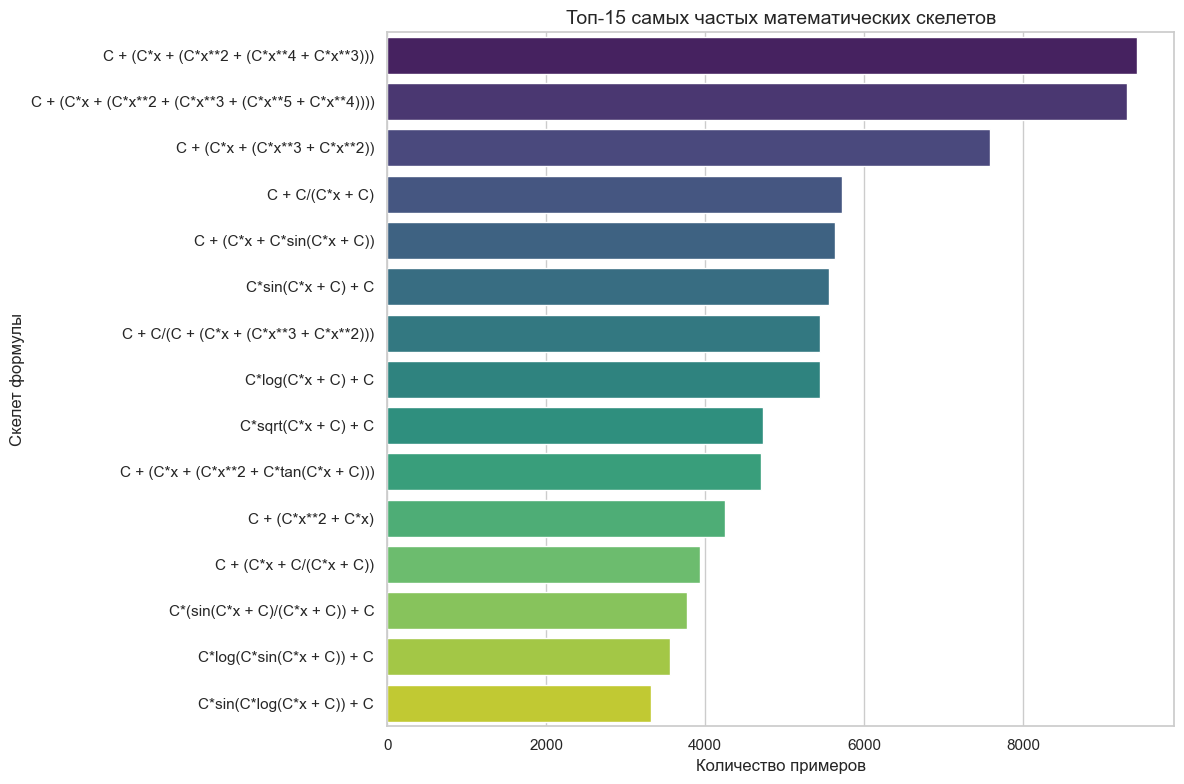

In [2]:
df_meta = pd.read_csv(METADATA_PATH)
print(f"Total dataset size: {len(df_meta):,} records")

unique_skeletons = df_meta['expr_str'].nunique()
print(f"Уникальных математических скелетов: {unique_skeletons:,}")

top_skeletons = df_meta['expr_str'].value_counts().head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_skeletons.values, y=top_skeletons.index, hue=top_skeletons.index, palette="viridis", legend=False)
plt.title('Топ-15 самых частых математических скелетов')
plt.xlabel('Количество примеров')
plt.ylabel('Скелет формулы')
plt.tight_layout()
plt.show()

## 2. Анализ длин последовательностей
Оценим распределение длины токенов (без учета паддинга). Это критично для настройки `max_seq_len` в трансформере, чтобы не тратить память на квадратичное внимание (self-attention) для пустых токенов.

Загружаем 57 файлов в память


100%|██████████| 57/57 [00:04<00:00, 11.59it/s]


Сбор статистики:   0%|          | 0/500000 [00:00<?, ?it/s]

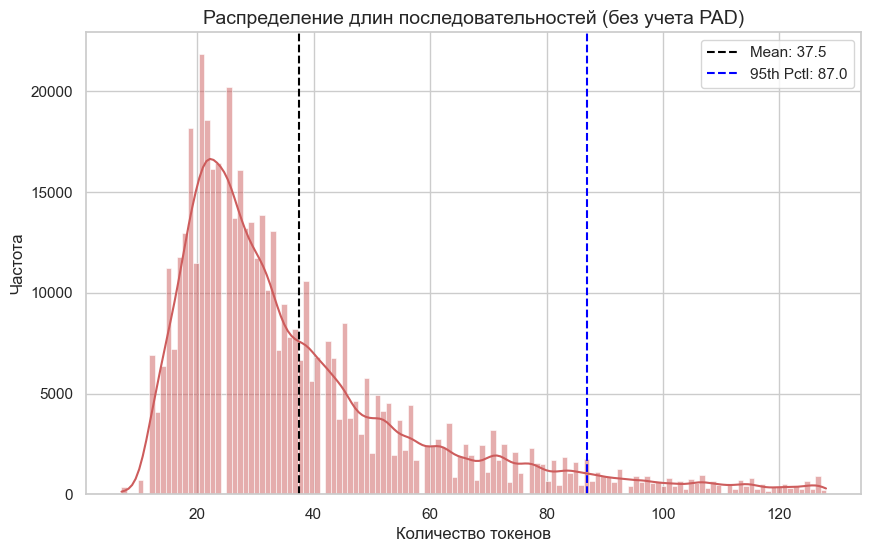

In [3]:
dataset = SymbolicDataset(data_dir=DATA_DIR)

SAMPLE_SIZE = 100_000
indices = random.sample(range(len(dataset)), SAMPLE_SIZE)

seq_lengths = []
valid_points_counts = []
all_y_values =[]
all_y_derivatives = []

for idx in tqdm(indices, desc="Сбор статистики"):
    points, tokens = dataset[idx] 
    
    seq_len = (tokens != 0).sum().item()
    seq_lengths.append(seq_len)
    
    y_vals = points[0, :]
    mask = points[1, :]
    
    valid_y = y_vals[mask == 1]
    valid_points_counts.append(valid_y.shape[0])
    
    all_y_values.append(valid_y[::10].numpy())
    
    if valid_y.shape[0] > 1:
        dy = torch.diff(valid_y).numpy()
        all_y_derivatives.append(dy[::5]) 

seq_lengths = np.array(seq_lengths)
valid_points_counts = np.array(valid_points_counts)
all_y_values = np.concatenate(all_y_values)
all_y_derivatives = np.concatenate(all_y_derivatives)

plt.figure(figsize=(10, 6))
sns.histplot(seq_lengths, bins=int(seq_lengths.max()), kde=True, color='indianred')
plt.title('Распределение длин последовательностей (без учета PAD)')
plt.xlabel('Количество токенов')
plt.ylabel('Частота')
plt.axvline(np.mean(seq_lengths), color='black', linestyle='--', label=f'Mean: {np.mean(seq_lengths):.1f}') # type: ignore
plt.axvline(np.percentile(seq_lengths, 95), color='blue', linestyle='--', label=f'95th Pctl: {np.percentile(seq_lengths, 95):.1f}')
plt.legend()
plt.show()

## 3. Геометрия входов: распределение координат и асимптот
Графики отнормированы в Bounding Box `[0, 1]`. Канал масок отвечает за валидность точек (отсекает асимптоты и точки вне области определения). Проверим, как это выглядит на уровне статистики.

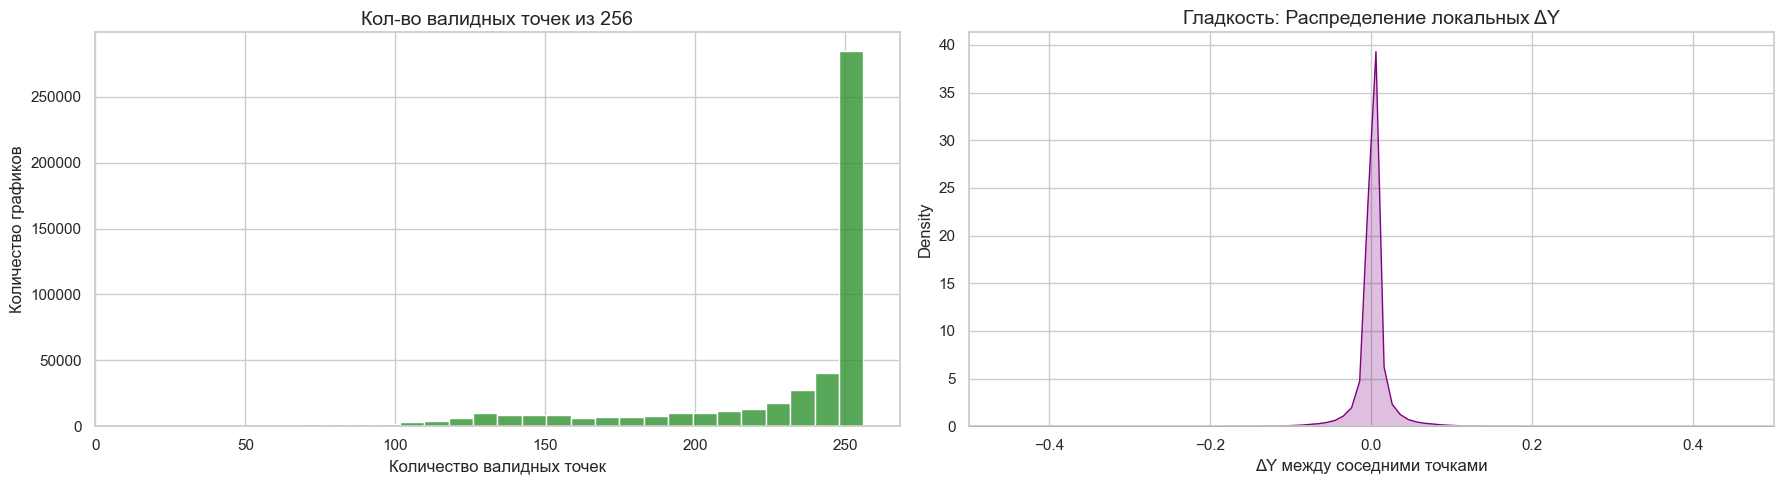

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(valid_points_counts, bins=30, ax=axes[0], color='forestgreen')
axes[0].set_title('Кол-во валидных точек из 256')
axes[0].set_xlabel('Количество валидных точек')
axes[0].set_ylabel('Количество графиков')

sns.kdeplot(all_y_derivatives, ax=axes[1], color='purple', fill=True)
axes[1].set_xlim(-0.5, 0.5)
axes[1].set_title('Гладкость: Распределение локальных ΔY')
axes[1].set_xlabel('ΔY между соседними точками')

plt.tight_layout()
plt.show()

## 4. Визуализация графиков с учетом масок (Sanity Check)
Убедимся, что пайплайн обработки данных корректно интерпретирует разрывы и не соединяет ветви гипербол и тангенсоид между собой.

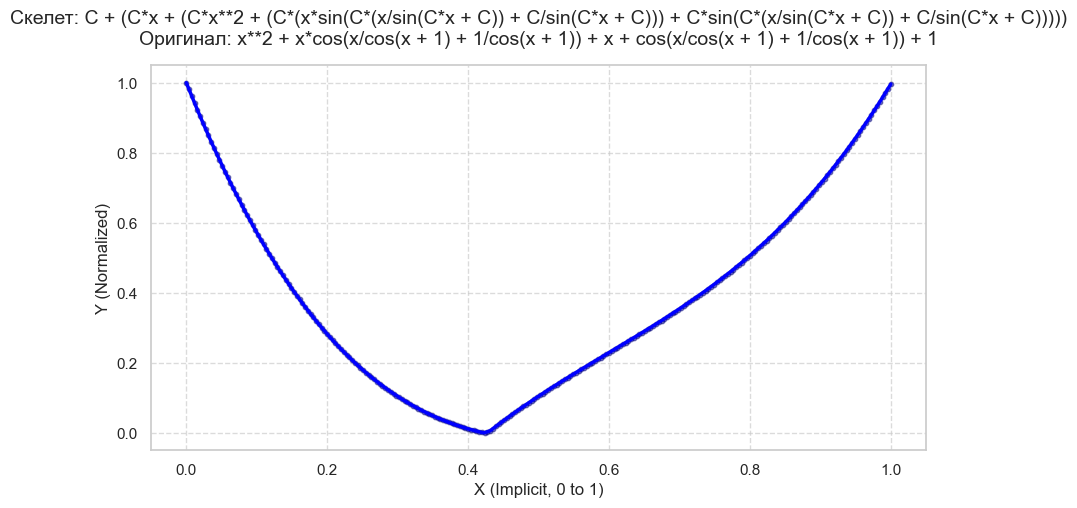

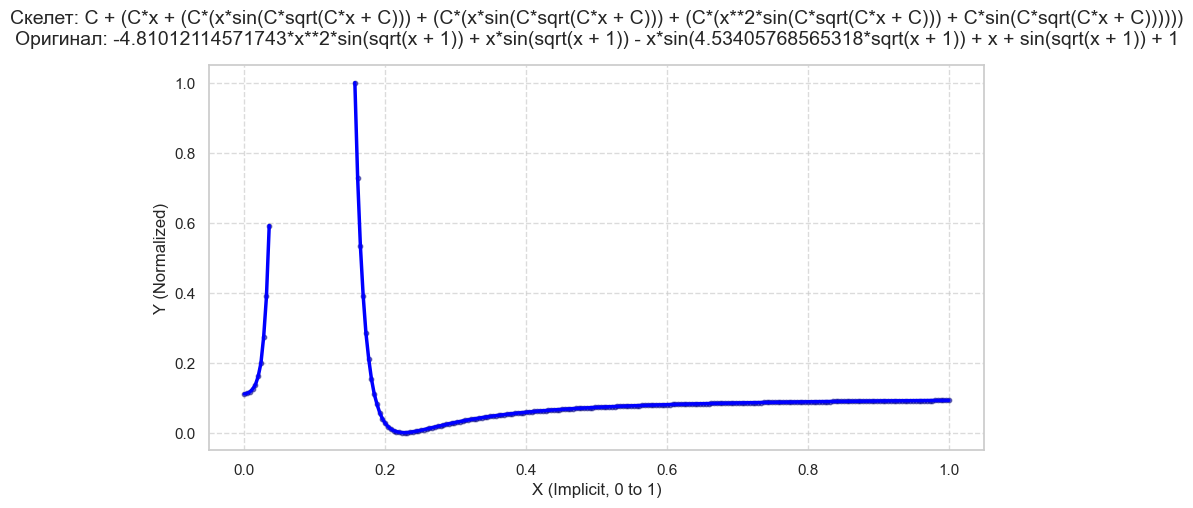

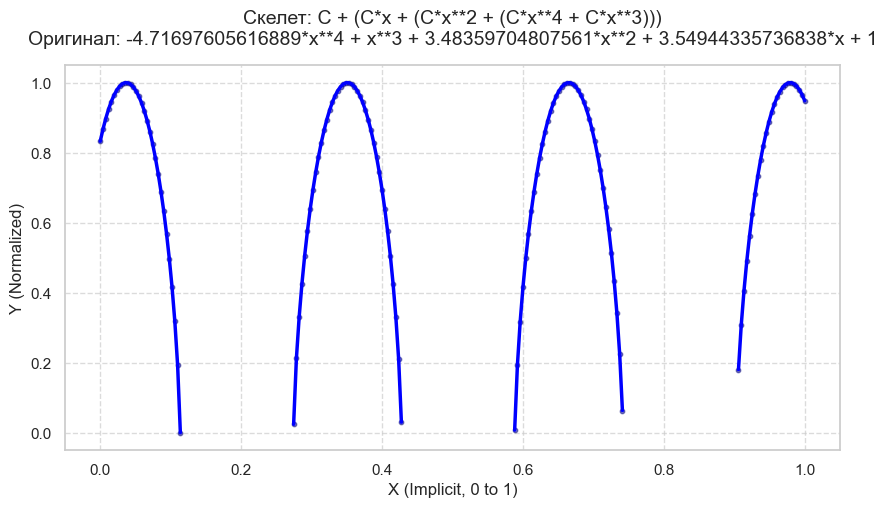

In [13]:
def plot_sample(idx, dataset, df_meta):
    points, tokens = dataset[idx]
    y_vals = points[0, :].numpy()
    mask = points[1, :].numpy()
    
    x_vals = np.linspace(0, 1, 256)
    
    meta_row = df_meta.iloc[idx]
    skeleton = meta_row['expr_str']
    original = meta_row['expr_instantiated_str']
    
    plt.figure(figsize=(10, 5))
    
    valid_indices = np.where(mask == 1)[0]
    if len(valid_indices) == 0:
        plt.text(0.5, 0.5, "Пустой график", ha='center')
    else:
        # Разбиваем точки на непрерывные сегменты по разрывам маски
        breaks = np.where(np.diff(valid_indices) > 1)[0]
        segments = np.split(valid_indices, breaks + 1)
        
        for seg in segments:
            plt.plot(x_vals[seg], y_vals[seg], color='blue', linewidth=2.5)
            plt.scatter(x_vals[seg], y_vals[seg], color='navy', s=10, alpha=0.5)

    plt.ylim(-0.05, 1.05)
    plt.xlim(-0.05, 1.05)
    plt.title(f"Скелет: {skeleton}\nОригинал: {original}", pad=15)
    plt.xlabel("X (Implicit, 0 to 1)")
    plt.ylabel("Y (Normalized)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Отрисовка примеров с потенциальными разрывами
samples_to_plot = [indices[104], indices[1000], indices[-10]]

for idx in samples_to_plot:
    plot_sample(idx, dataset, df_meta)